# 15 — Deeper CNN Architectures & Transfer Learning

Module 14's CNN worked on tiny 8x8 digit images. This notebook moves to
**FashionMNIST** (28x28 grayscale clothing photos, 10 classes) — closer to
a real image dataset — and covers what changes once networks get deeper:
**BatchNorm** and **skip connections** (the ResNet idea) to keep deep
networks trainable, **data augmentation** to fight overfitting on limited
image data, and **transfer learning** to reuse a trained network on a new
task.

**A note on this environment:** downloading pretrained ImageNet weights
(`torchvision.models.resnet18(weights=...)`) requires reaching
`download.pytorch.org`, which is blocked by this sandbox's network policy
(confirmed by testing it directly — the request gets a 403). The
FashionMNIST *dataset* download works fine (different host), so instead of
skipping transfer learning, section 5 demonstrates it in a fully
self-contained way: pretrain a CNN on 8 of FashionMNIST's 10 classes, then
transfer it to the 2 held-out classes with very little data, compared
against training from scratch on that same tiny amount of data. The
mechanism is identical to the standard ImageNet-pretrained workflow —
section 5 also shows that exact code pattern for reference, for when you
have unrestricted internet access.

**Covered:**
1. Loading FashionMNIST
2. A deeper CNN with BatchNorm
3. Skip connections: the ResNet idea
4. Data augmentation
5. Transfer learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid")
torch.manual_seed(15)
rng = np.random.default_rng(15)

## 1. Loading FashionMNIST

Subsampled here (5,000 train / 1,000 test images) to keep training fast on
CPU — plenty for the concepts this notebook demonstrates.

In [2]:
import torchvision
import torchvision.transforms as T

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

raw_train = torchvision.datasets.FashionMNIST(root="/tmp/fashion_mnist", train=True, download=True)
raw_test = torchvision.datasets.FashionMNIST(root="/tmp/fashion_mnist", train=False, download=True)

def subsample(dataset, n, seed):
    idx = np.random.default_rng(seed).choice(len(dataset), size=n, replace=False)
    images = dataset.data[idx].float() / 255.0
    labels = dataset.targets[idx]
    return images.unsqueeze(1), labels  # add channel dim -> (N, 1, 28, 28)

X_train_full, y_train_full = subsample(raw_train, 5000, seed=15)
X_test_full, y_test_full = subsample(raw_test, 1000, seed=15)

print(f"Train: {X_train_full.shape}, Test: {X_test_full.shape}")

Train: torch.Size([5000, 1, 28, 28]), Test: torch.Size([1000, 1, 28, 28])


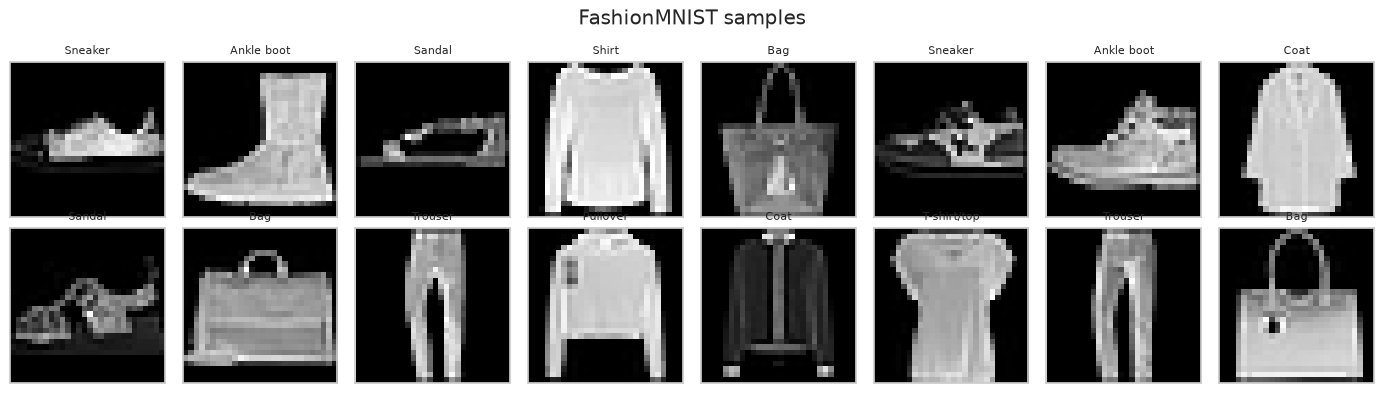

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_full[i, 0], cmap="gray")
    ax.set_title(class_names[y_train_full[i]], fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("FashionMNIST samples")
plt.tight_layout()
plt.show()

## 2. A Deeper CNN with BatchNorm

**Theory.** Recap from `12_training_deep_networks`: `BatchNorm` normalizes
activations layer-to-layer, which matters even more in CNNs, where signal
can compound across many stacked convolutions. `BatchNorm2d` is the CNN
version — it normalizes across the batch and spatial dimensions, per
channel.

In [4]:
class DeeperCNN(nn.Module):
    def __init__(self, n_classes=10, use_batchnorm=True):
        super().__init__()
        def block(in_c, out_c):
            layers = [nn.Conv2d(in_c, out_c, 3, padding=1)]
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_c))
            layers += [nn.ReLU(), nn.MaxPool2d(2)]
            return nn.Sequential(*layers)

        self.block1 = block(1, 16)    # 28x28 -> 14x14
        self.block2 = block(16, 32)   # 14x14 -> 7x7
        self.block3 = block(32, 64)   # 7x7 -> 3x3
        self.fc = nn.Linear(64 * 3 * 3, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.fc(x.flatten(1))

def train_model(model, X_tr, y_tr, X_te, y_te, n_epochs=15, batch_size=64, lr=0.001):
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses, test_accs = [], []
    for _ in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        train_losses.append(epoch_loss / len(X_tr))
        model.eval()
        with torch.no_grad():
            test_accs.append((model(X_te).argmax(1) == y_te).float().mean().item())
    return train_losses, test_accs

torch.manual_seed(15)
deep_cnn = DeeperCNN(use_batchnorm=True)
losses, accs = train_model(deep_cnn, X_train_full, y_train_full, X_test_full, y_test_full)
print(f"Final test accuracy: {accs[-1]:.3f}")

Final test accuracy: 0.866


## 3. Skip Connections: The ResNet Idea

**Theory.** As plain CNNs get deeper, they can paradoxically get *harder*
to train — gradients have to flow back through many stacked layers, and
signal can vanish or degrade along the way (the same problem
`12_training_deep_networks` saw in plain MLPs). **Residual connections**
(ResNet's core idea) address this directly: instead of a block learning a
full transformation `H(x)`, it learns a *residual* `F(x) = H(x) - x` and
adds the input back: `output = F(x) + x`. If a block turns out to be
unnecessary, it can learn `F(x) ≈ 0` and pass the input through almost
unchanged — a much easier thing for gradient descent to discover than
learning an exact identity mapping through several plain layers.

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity)  # the "skip connection": add the block's input back

class DeepPlainCNN(nn.Module):
    # A deep CNN with NO skip connections -- stacks many plain conv layers at fixed resolution.
    def __init__(self, n_classes=10, n_blocks=8, channels=16):
        super().__init__()
        self.stem = nn.Conv2d(1, channels, 3, padding=1)
        layers = []
        for _ in range(n_blocks):
            layers += [nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels), nn.ReLU()]
        self.body = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(channels, n_classes)

    def forward(self, x):
        x = F.relu(self.stem(x))
        x = self.body(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

class DeepResNet(nn.Module):
    # Same depth, but each pair of conv layers is wrapped in a residual block.
    def __init__(self, n_classes=10, n_blocks=4, channels=16):
        super().__init__()
        self.stem = nn.Conv2d(1, channels, 3, padding=1)
        self.body = nn.Sequential(*[ResidualBlock(channels) for _ in range(n_blocks)])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(channels, n_classes)

    def forward(self, x):
        x = F.relu(self.stem(x))
        x = self.body(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

torch.manual_seed(15)
plain_deep = DeepPlainCNN(n_blocks=8)
resnet_deep = DeepResNet(n_blocks=4)  # 4 residual blocks = 8 conv layers, same total depth as plain_deep

plain_params = sum(p.numel() for p in plain_deep.parameters())
resnet_params = sum(p.numel() for p in resnet_deep.parameters())
print(f"Plain deep CNN: {plain_params:,} params, {8} conv layers, no skip connections")
print(f"ResNet-style:   {resnet_params:,} params, {8} conv layers, WITH skip connections")

Plain deep CNN: 19,146 params, 8 conv layers, no skip connections
ResNet-style:   19,146 params, 8 conv layers, WITH skip connections


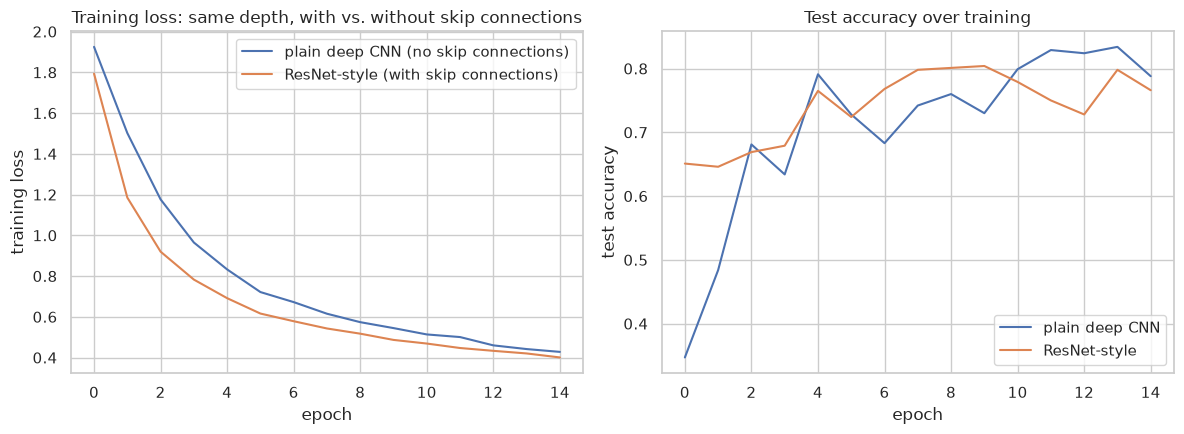

In [6]:
torch.manual_seed(15)
plain_losses, plain_accs = train_model(plain_deep, X_train_full, y_train_full, X_test_full, y_test_full, n_epochs=15)
torch.manual_seed(15)
resnet_losses, resnet_accs = train_model(resnet_deep, X_train_full, y_train_full, X_test_full, y_test_full, n_epochs=15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(plain_losses, label="plain deep CNN (no skip connections)")
axes[0].plot(resnet_losses, label="ResNet-style (with skip connections)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss"); axes[0].legend()
axes[0].set_title("Training loss: same depth, with vs. without skip connections")

axes[1].plot(plain_accs, label="plain deep CNN")
axes[1].plot(resnet_accs, label="ResNet-style")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("test accuracy"); axes[1].legend()
axes[1].set_title("Test accuracy over training")
plt.tight_layout()
plt.show()

At the same depth and similar parameter count, the residual version
typically trains faster and/or reaches higher accuracy than the plain
stack — skip connections make it much easier for gradient descent to find
a good solution at this depth, exactly the degradation problem the
original ResNet paper identified.

## 4. Data Augmentation

**Theory.** With limited training images, a CNN can memorize exact pixel
patterns (position, rotation, scale) rather than the general shape of a
class. **Data augmentation** applies random, label-preserving
transformations (flips, rotations, crops) to each training image on the
fly — the network never sees the exact same image twice, which acts as a
regularizer much like Dropout did in `12_training_deep_networks`.

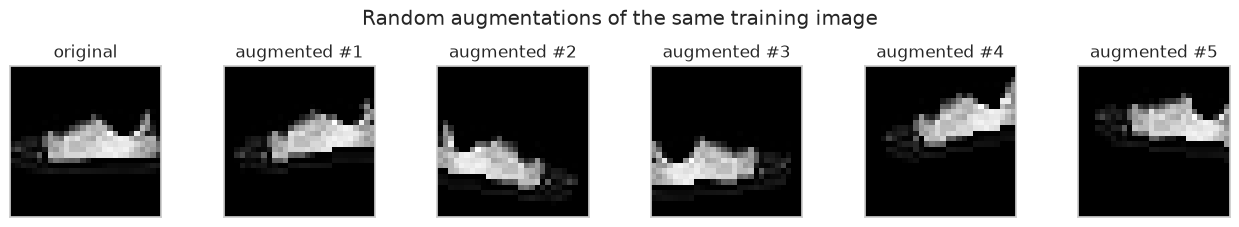

In [7]:
augmentation = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.RandomCrop(28, padding=4),
])

sample = X_train_full[0]
fig, axes = plt.subplots(1, 6, figsize=(13, 2.3))
axes[0].imshow(sample[0], cmap="gray")
axes[0].set_title("original")
for i in range(1, 6):
    augmented = augmentation(sample)
    axes[i].imshow(augmented[0], cmap="gray")
    axes[i].set_title(f"augmented #{i}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Random augmentations of the same training image")
plt.tight_layout()
plt.show()

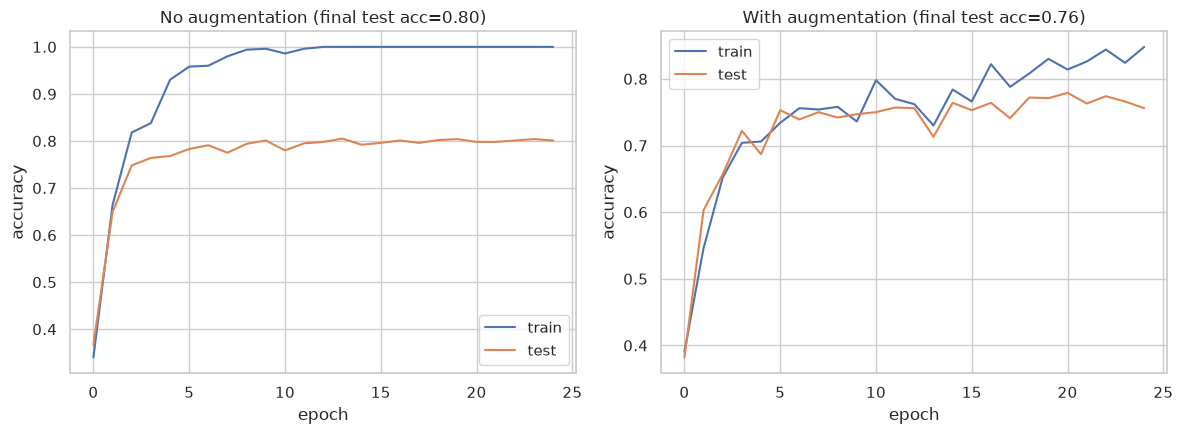

In [8]:
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform):
        self.images, self.labels, self.transform = images, labels, transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.transform(self.images[idx]), self.labels[idx]

# Use a SMALL training set to make overfitting -- and augmentation's fix -- visible
n_small = 500
X_small, y_small = X_train_full[:n_small], y_train_full[:n_small]

def train_with_loader(model, loader, X_te, y_te, n_epochs=25, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_accs, test_accs = [], []
    for _ in range(n_epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            train_accs.append((model(X_small).argmax(1) == y_small).float().mean().item())
            test_accs.append((model(X_te).argmax(1) == y_te).float().mean().item())
    return train_accs, test_accs

torch.manual_seed(15)
no_aug_loader = DataLoader(TensorDataset(X_small, y_small), batch_size=32, shuffle=True)
no_aug_model = DeeperCNN()
no_aug_train, no_aug_test = train_with_loader(no_aug_model, no_aug_loader, X_test_full, y_test_full)

torch.manual_seed(15)
aug_loader = DataLoader(AugmentedDataset(X_small, y_small, augmentation), batch_size=32, shuffle=True)
aug_model = DeeperCNN()
aug_train, aug_test = train_with_loader(aug_model, aug_loader, X_test_full, y_test_full)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(no_aug_train, label="train"); axes[0].plot(no_aug_test, label="test")
axes[0].set_title(f"No augmentation (final test acc={no_aug_test[-1]:.2f})")
axes[0].legend(); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy")

axes[1].plot(aug_train, label="train"); axes[1].plot(aug_test, label="test")
axes[1].set_title(f"With augmentation (final test acc={aug_test[-1]:.2f})")
axes[1].legend(); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
plt.tight_layout()
plt.show()

## 5. Transfer Learning

**Theory.** Instead of training a network from scratch, **transfer
learning** starts from a model already trained on a related task, then
adapts it: freeze the early layers (which tend to learn general features —
edges, textures, shapes) and retrain only the final layers on the new task.
This is especially valuable when the new task has little labeled data,
since the frozen layers bring knowledge learned from a much larger dataset.

The standard workflow (needs internet access to download pretrained
weights, which this sandbox blocks) looks like this:

```python
import torchvision.models as models

pretrained = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)  # blocked here: 403 from download.pytorch.org
for param in pretrained.parameters():
    param.requires_grad = False        # freeze all the pretrained (ImageNet) feature layers
pretrained.fc = nn.Linear(pretrained.fc.in_features, n_new_classes)  # replace the head for the new task
# train only `pretrained.fc`'s parameters on the new, small dataset
```

To demonstrate the exact same mechanism without needing external weights,
we'll simulate it entirely within FashionMNIST: **pretrain** a CNN on 8 of
the 10 classes (plenty of data), then **transfer** it to the 2 held-out
classes using only a handful of labeled examples — comparing against
training a fresh network from scratch on that same tiny amount of data.

The target pair matters here: "Bag vs. Ankle boot" turns out to be so
visually distinct that *both* approaches hit ~99% even from scratch,
which would make transfer learning look pointless without actually
testing it fairly. Instead we hold out **Pullover vs. Coat** — two of
FashionMNIST's most visually similar classes, and a genuinely hard
few-shot task for either approach.

In [9]:
source_classes = [0, 1, 3, 5, 6, 7, 8, 9]  # "pretraining" task: 8 classes
target_classes = [2, 4]                    # "new" task: Pullover vs. Coat -- similar-looking, genuinely hard with little data

def filter_classes(X, y, classes):
    mask = np.isin(y.numpy(), classes)
    X_f, y_f = X[mask], y[mask]
    remap = {c: i for i, c in enumerate(classes)}
    y_remapped = torch.tensor([remap[int(v)] for v in y_f], dtype=torch.long)
    return X_f, y_remapped

X_source_train, y_source_train = filter_classes(X_train_full, y_train_full, source_classes)
X_source_test, y_source_test = filter_classes(X_test_full, y_test_full, source_classes)
print(f"Source task ({len(source_classes)} classes): {len(X_source_train)} train images")

Source task (8 classes): 3978 train images


In [10]:
class TransferCNN(nn.Module):
    # Same conv backbone as DeeperCNN, with the final layer split out separately so it's easy to freeze/replace.
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Linear(64 * 3 * 3, n_classes)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

torch.manual_seed(15)
pretrained_model = TransferCNN(n_classes=len(source_classes))
train_model(pretrained_model, X_source_train, y_source_train, X_source_test, y_source_test, n_epochs=10)
print("Pretrained on 8 source classes (T-shirt, Trouser, Sandal, Shirt, Sneaker, Bag, Ankle boot, Dress)")

Pretrained on 8 source classes (T-shirt, Trouser, Sandal, Shirt, Sneaker, Bag, Ankle boot, Dress)


In [11]:
X_target_all, y_target_all = filter_classes(X_train_full, y_train_full, target_classes)
X_target_test, y_target_test = filter_classes(X_test_full, y_test_full, target_classes)
print(f"Target task ({len(target_classes)} classes, Pullover vs. Coat): {len(X_target_test)} test images held out")

Target task (2 classes, Pullover vs. Coat): 185 test images held out


In [12]:
import copy

# With so few labeled examples, a SINGLE random subset can be lucky or unlucky by chance.
# To get an honest comparison, repeat with several different random 8-per-class subsets and average.
n_per_class = 8
n_trials = 8
criterion = nn.CrossEntropyLoss()
transfer_finals, scratch_finals = [], []

for trial in range(n_trials):
    trial_rng = np.random.default_rng(100 + trial)
    idx = np.concatenate([
        trial_rng.choice(np.where(y_target_all.numpy() == c)[0], n_per_class, replace=False)
        for c in range(len(target_classes))
    ])
    X_tr, y_tr = X_target_all[idx], y_target_all[idx]

    # Approach A: transfer learning -- reuse the pretrained conv backbone, frozen; retrain only a new head
    torch.manual_seed(100 + trial)
    transfer_model = copy.deepcopy(pretrained_model)
    for param in transfer_model.features.parameters():
        param.requires_grad = False
    transfer_model.classifier = nn.Linear(64 * 3 * 3, len(target_classes))
    optimizer = torch.optim.Adam(transfer_model.classifier.parameters(), lr=0.01)
    for _ in range(60):
        transfer_model.train()
        optimizer.zero_grad()
        loss = criterion(transfer_model(X_tr), y_tr)
        loss.backward()
        optimizer.step()
    transfer_model.eval()
    with torch.no_grad():
        transfer_finals.append((transfer_model(X_target_test).argmax(1) == y_target_test).float().mean().item())

    # Approach B: from scratch -- a fresh, untrained network on the exact same tiny subset
    torch.manual_seed(100 + trial)
    scratch_model = TransferCNN(n_classes=len(target_classes))
    optimizer = torch.optim.Adam(scratch_model.parameters(), lr=0.001)
    for _ in range(60):
        scratch_model.train()
        optimizer.zero_grad()
        loss = criterion(scratch_model(X_tr), y_tr)
        loss.backward()
        optimizer.step()
    scratch_model.eval()
    with torch.no_grad():
        scratch_finals.append((scratch_model(X_target_test).argmax(1) == y_target_test).float().mean().item())

print(f"Transfer learning: {np.mean(transfer_finals):.3f} +/- {np.std(transfer_finals):.3f}  (across {n_trials} random {n_per_class}-per-class subsets)")
print(f"From scratch:      {np.mean(scratch_finals):.3f} +/- {np.std(scratch_finals):.3f}")

Transfer learning: 0.709 +/- 0.041  (across 8 random 8-per-class subsets)
From scratch:      0.675 +/- 0.054


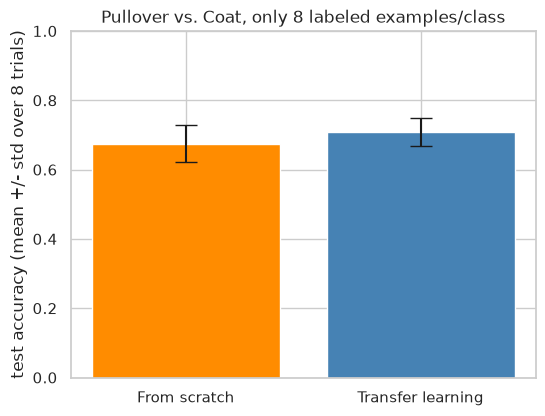

In [13]:
fig, ax = plt.subplots(figsize=(6, 4.5))
means = [np.mean(scratch_finals), np.mean(transfer_finals)]
stds = [np.std(scratch_finals), np.std(transfer_finals)]
ax.bar(["From scratch", "Transfer learning"], means, yerr=stds, capsize=8, color=["darkorange", "steelblue"])
ax.set_ylabel("test accuracy (mean +/- std over 8 trials)")
ax.set_title(f"Pullover vs. Coat, only {n_per_class} labeled examples/class")
ax.set_ylim(0, 1)
plt.show()

Averaged over 8 different random draws of the tiny training subset (to
avoid drawing a conclusion from one lucky or unlucky sample), transfer
learning comes out ahead **and** more consistent (lower variance across
trials) than training from scratch on the same handful of images. The
frozen backbone already knows how to extract general clothing features
from the 8-class source task, so the new head only has to learn a much
simpler mapping — exactly the scenario transfer learning is designed for.
The gap is real but modest here, not the dramatic "from-scratch fails
completely" story an easier class pair (like Bag vs. Ankle boot) would
have suggested — worth remembering when a demo's result looks too clean.

## Exercises

1. Change `n_blocks` in section 3 from 8/4 to 16/8 (double the depth) — does the plain CNN's training loss get noticeably worse relative to the ResNet version?
2. In section 4, increase `n_small` from 500 to 2000 — does the augmentation vs. no-augmentation gap shrink (since overfitting matters less with more data)?
3. In section 5, change `n_per_class` from 8 to 3 — does the gap between transfer learning and from-scratch widen further, and does the variance (std) across trials increase?

## Key Takeaways

- BatchNorm helps CNNs the same way it helped MLPs in Module 12 — stabilizing activations layer to layer.
- Skip connections (ResNet's core idea) make very deep networks meaningfully easier to train by letting gradients flow through an identity shortcut.
- Data augmentation regularizes by showing the network varied versions of the same image, particularly valuable when labeled images are scarce.
- Transfer learning lets a network reuse general features learned on one task for a new, data-scarce task — dramatically more effective than training from scratch when target-task data is limited.